In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [38]:
data=pd.read_csv('Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [39]:
x=data.iloc[:,[2,3]].values
y=data.iloc[:,4].values

In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0,stratify=y)

In [41]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [43]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(x_train,y_train)
y_pred=classifier.predict(x_test)


In [46]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,recall_score,precision_score,f1_score
cm=confusion_matrix(y_test,y_pred)
print(cm)   
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print("Recall Score:", recall_score(y_test, y_pred))
print("Precision Score:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

[[47  4]
 [11 18]]
0.8125
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        51
           1       0.82      0.62      0.71        29

    accuracy                           0.81        80
   macro avg       0.81      0.77      0.78        80
weighted avg       0.81      0.81      0.81        80

Recall Score: 0.6206896551724138
Precision Score: 0.8181818181818182
F1 Score: 0.7058823529411765


In [48]:
tp,tn,fp,fn=cm.ravel()
print("True Positives:", tp)
print("True Negatives:", tn)
print("False Positives:", fp)   
print("False Negatives:", fn)

True Positives: 47
True Negatives: 4
False Positives: 11
False Negatives: 18


In [49]:
def accuracy_sc(tp,tn,fp,fn):
    return (tp+tn)/(tp+tn+fp+fn)

In [50]:
accuracy_sc(tp,tn,fp,fn)

np.float64(0.6375)

In [52]:
acc=accuracy_score(y_test,y_pred)
recall=recall_score(y_test, y_pred)
precision=precision_score(y_test, y_pred)
f1_sv=f1_score(y_test, y_pred)
print("Accuracy Score:", acc)
print("Recall Score:", recall)
print("Precision Score:", precision)
print("F1 Score:", f1_sv)

Accuracy Score: 0.8125
Recall Score: 0.6206896551724138
Precision Score: 0.8181818181818182
F1 Score: 0.7058823529411765


C:\Users\ADAM-LAP\AppData\Local\Temp\ipykernel_23936\2522940178.py:23: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


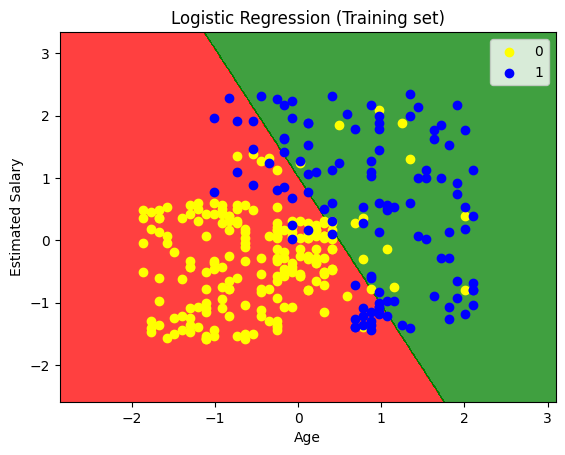

In [60]:

from matplotlib.colors import ListedColormap


X_Set, Y_Set = x_train, y_train  

X1, X2 = np.meshgrid(
    np.arange(start = X_Set[:,0].min() - 1, stop = X_Set[:,0].max() + 1, step = 0.01),
    np.arange(start = X_Set[:,1].min() - 1, stop = X_Set[:,1].max() + 1, step = 0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha = 0.75,
    cmap = ListedColormap(('red', 'green'))
)


plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(
        X_Set[Y_Set == j, 0], 
        X_Set[Y_Set == j, 1],
        c = ListedColormap(('yellow', 'blue'))(i),
        label = j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()